## Convert C3D file to TRC and MOT files

In [1]:
import ezc3d
import numpy as np
import os
import pandas as pd

In [51]:
folder = '../GitHub/TeamProject/data/DB4_retargeted/P06'
files = [f for f in os.listdir(folder) if f.endswith('.c3d')]  # Get list of all .c3d files

print(f"Found {len(files)} C3D files to process.")

Found 3 C3D files to process.


In [52]:
print("Starting TRC and MOT conversion...")
#relabeled_files = [f for f in os.listdir(folder) if f.endswith('_relabeled.c3d')]
relabeled_files = [f for f in os.listdir(folder) if f.endswith('.c3d')]

for file_name in relabeled_files:
    file_path = os.path.join(folder, file_name)
    c3d_data = ezc3d.c3d(file_path)
    
    # 1. TRC Exporter (Markers)
    trc_path = file_path.replace('.c3d', '.trc')
    
    points = c3d_data['data']['points']
    labels = c3d_data['parameters']['POINT']['LABELS']['value']
    rate = c3d_data['parameters']['POINT']['RATE']['value'][0]
    units = c3d_data['parameters']['POINT']['UNITS']['value'][0]
    
    num_markers = len(labels)
    num_frames = points.shape[2]
    
    scale_factor = 0.001 if units == 'mm' else 1.0 # OpenSim expects meters. Scale if the C3D is in millimeters.
    
    with open(trc_path, 'w') as f:
        # Header
        f.write(f"PathFileType\t4\t(X/Y/Z)\t{file_name}\n")
        f.write("DataRate\tCameraRate\tNumFrames\tNumMarkers\tUnits\tOrigDataRate\tOrigDataStartFrame\tOrigNumFrames\n")
        f.write(f"{rate}\t{rate}\t{num_frames}\t{num_markers}\tm\t{rate}\t1\t{num_frames}\n")
        # Labels
        f.write("Frame#\tTime\t")
        for label in labels:
            f.write(f"{label}\t\t\t")
        f.write("\n\t\t")
        # XYZ Columns
        for i in range(num_markers):
            f.write(f"X{i+1}\tY{i+1}\tZ{i+1}\t")
        f.write("\n")
        # Data
        for frame in range(num_frames):
            time = frame / rate
            f.write(f"{frame+1}\t{time:.5f}\t")
            for m in range(num_markers):
                # 1. Grab the original lab coordinates
                orig_x = points[0, m, frame] * scale_factor
                orig_y = points[1, m, frame] * scale_factor
                orig_z = points[2, m, frame] * scale_factor
                
                # 2. Swap them to match OpenSim's Y-up system
                x = orig_x   # OpenSim Forward (X) is Lab Forward (X)
                y = orig_z   # OpenSim Up (Y) is Lab Up (Z)
                z = -orig_y  # OpenSim Right (Z) is Lab Right (-Y)
                
                # 3. Write the swapped values
                f.write(f"{x:.5f}\t{y:.5f}\t{z:.5f}\t")
            f.write("\n")
    print(f"Created TRC: {os.path.basename(trc_path)}")

    # 2. MOT Exporter (Forces, CoP, Free Torque)
    mot_path = file_path.replace('.c3d', '.mot')
    
    if 'ANALOG' in c3d_data['parameters'] and c3d_data['parameters']['ANALOG']['USED']['value'][0] > 0:
        analogs = c3d_data['data']['analogs'][0] 
        analog_labels = [str(lbl).strip() for lbl in c3d_data['parameters']['ANALOG']['LABELS']['value']]
        analog_rate = c3d_data['parameters']['ANALOG']['RATE']['value'][0]
        
        num_analog_frames = analogs.shape[1]
        label_to_idx = {lbl: i for i, lbl in enumerate(analog_labels)}
        
        # Check units from the C3D to scale moments (Nmm to Nm)
        # We reuse the scale_factor from the TRC section (0.001 if mm, 1.0 if m)
        units = c3d_data['parameters']['POINT']['UNITS']['value'][0]
        scale_factor = 0.001 if units == 'mm' else 1.0
        
        # Find how many force plates we have by looking for 'Fz' labels
        plate_numbers = [lbl.replace('Fz', '') for lbl in analog_labels if 'Fz' in lbl]
        
        with open(mot_path, 'w') as f:
            # Header
            # 9 columns per plate (3 Force, 3 Point, 3 Torque) + 1 Time column
            num_cols = (len(plate_numbers) * 9) + 1 
            f.write(f"{file_name}_forces\nversion=1\nnRows={num_analog_frames}\nnColumns={num_cols}\ninDegrees=no\nendheader\n")
            
            # Column Headers (Strict OpenSim Naming Convention)
            f.write("time\t")
            for p in plate_numbers:
                f.write(f"ground_force_{p}_vx\tground_force_{p}_vy\tground_force_{p}_vz\t")
                f.write(f"ground_force_{p}_px\tground_force_{p}_py\tground_force_{p}_pz\t")
                f.write(f"ground_moment_{p}_mx\tground_moment_{p}_my\tground_moment_{p}_mz\t")
            f.write("\n")
            
            # Data Rows
            for frame in range(num_analog_frames):
                time = frame / analog_rate
                f.write(f"{time:.5f}\t")
                
                for p in plate_numbers:
                    # 1. Grab raw lab data for this specific plate
                    fx = analogs[label_to_idx.get(f'Fx{p}', -1), frame]
                    fy = analogs[label_to_idx.get(f'Fy{p}', -1), frame]
                    fz = analogs[label_to_idx.get(f'Fz{p}', -1), frame]
                    
                    # Scale the moments to Nm
                    mx = analogs[label_to_idx.get(f'Mx{p}', -1), frame] * scale_factor
                    my = analogs[label_to_idx.get(f'My{p}', -1), frame] * scale_factor
                    mz = analogs[label_to_idx.get(f'Mz{p}', -1), frame] * scale_factor
                    
                    # 2. Threshold check: Is the foot actually on the plate? (e.g., > 20 Newtons)
                    if abs(fz) > 20.0:
                        # Calculate Lab CoP
                        cop_x = -my / fz
                        cop_y = mx / fz
                        cop_z = 0.0 # Floor surface
                        
                        # Calculate Lab Free Torque around the Z axis
                        t_x = 0.0
                        t_y = 0.0
                        t_z = mz - (cop_x * fy) + (cop_y * fx)
                    else:
                        # If nobody is stepping on it, zero everything out to prevent noise/math errors
                        fx, fy, fz = 0.0, 0.0, 0.0
                        cop_x, cop_y, cop_z = 0.0, 0.0, 0.0
                        t_x, t_y, t_z = 0.0, 0.0, 0.0

                    # 3. ROTATE to OpenSim Y-up AND INVERT for Newton's 3rd Law
                    # Lab X -> OpenSim X
                    # Lab Z -> OpenSim Y
                    # Lab -Y -> OpenSim Z
                    
                    # Forces (Inverted)
                    os_fx = -fx
                    os_fy = -fz
                    os_fz = -(-fy) # The double negative makes it positive fy
                    
                    # CoP Positions (NOT inverted, just rotated)
                    os_px = cop_x
                    os_py = cop_z
                    os_pz = -cop_y
                    
                    # Torques (Inverted)
                    os_tx = -t_x
                    os_ty = -t_z
                    os_tz = -(-t_y)
                    
                    # 4. Write the 9 values for this plate
                    vals = [os_fx, os_fy, os_fz, os_px, os_py, os_pz, os_tx, os_ty, os_tz]
                    for v in vals:
                        # Catch any stray NaNs just in case
                        f.write("0.00000\t" if np.isnan(v) else f"{v:.5f}\t")
                        
                f.write("\n")
                
        print(f"Created MOT: {os.path.basename(mot_path)}")
    else:
        print(f"Skipped MOT for {file_name}: No analog data found.")

print("\nProcess complete! TRC and MOT files saved to the output folder.")

Starting TRC and MOT conversion...
Created TRC: DB4_P06_T01_relabeled.trc
Created MOT: DB4_P06_T01_relabeled.mot
Created TRC: DB4_P06_T03_relabeled.trc
Created MOT: DB4_P06_T03_relabeled.mot
Created TRC: DB4_P06_T04_relabeled.trc
Created MOT: DB4_P06_T04_relabeled.mot

Process complete! TRC and MOT files saved to the output folder.


## Visualize data

Setting up visualizations...
Visualizing TRC: DB4_P06_T01_relabeled.trc
Visualizing MOT: DB4_P06_T01_relabeled.mot


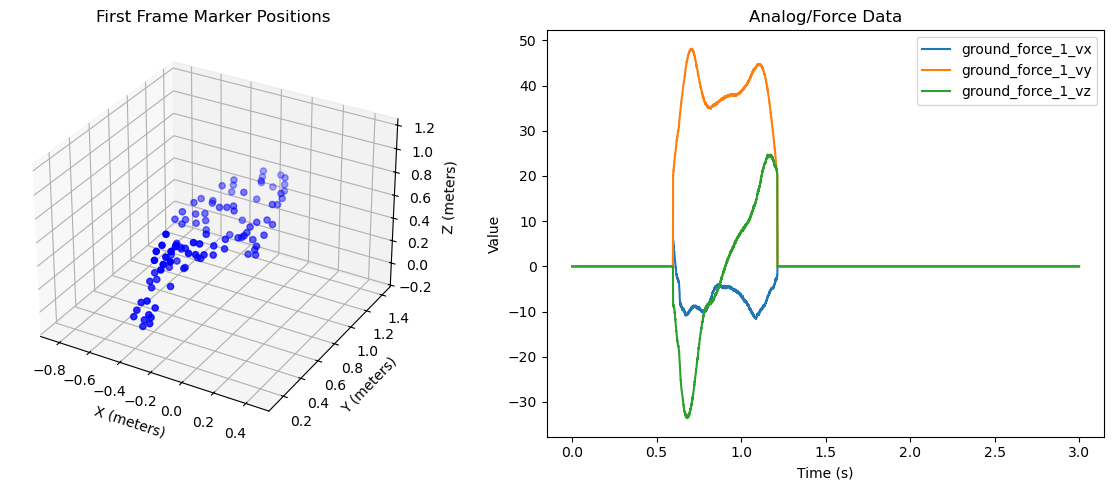

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

path_no = 0

print("Setting up visualizations...")

# Grab the first TRC and MOT file from your output folder
trc_files = [f for f in os.listdir(folder) if f.endswith('.trc')]
mot_files = [f for f in os.listdir(folder) if f.endswith('.mot')]

if not trc_files:
    print("No TRC files found to visualize.")
else:
    # 1. Visualize TRC (3D Marker Plot of Frame 1)
    trc_path = os.path.join(folder, trc_files[path_no])
    print(f"Visualizing TRC: {trc_files[path_no]}")
    # TRC files have 5 lines of headers
    df_trc = pd.read_csv(trc_path, sep='\t', skiprows=5, header=None)
    # Extract the very first frame (row 0)
    frame_data = df_trc.iloc[0].values
    # Isolate just the coordinate data (skip Frame and Time at indices 0 and 1)
    coords = frame_data[2:]
    # Calculate exactly how many full X, Y, Z marker triplets exist
    # This safely ignores any trailing empty columns pandas might have picked up
    num_triplets = len(coords) // 3
    # Slice into X, Y, and Z arrays of identical lengths and force them to be floats
    xs = np.array(coords[0::3][:num_triplets], dtype=float)
    ys = np.array(coords[1::3][:num_triplets], dtype=float)
    zs = np.array(coords[2::3][:num_triplets], dtype=float)
    
    # Create a mask that drops a marker only if it has NaN values
    valid_idx = ~(np.isnan(xs) | np.isnan(ys) | np.isnan(zs))
    # Apply the mask
    xs, ys, zs = xs[valid_idx], ys[valid_idx], zs[valid_idx]

    # Plotting
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.scatter(xs, ys, zs, c='b', marker='o')
    ax1.set_title('First Frame Marker Positions')
    ax1.set_xlabel('X (meters)')
    ax1.set_ylabel('Y (meters)')
    ax1.set_zlabel('Z (meters)')
    
    # Equalize axis limits so the body doesn't look stretched
    max_range = max(xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()) / 2.0
    mid_x, mid_y, mid_z = (xs.max()+xs.min())/2, (ys.max()+ys.min())/2, (zs.max()+zs.min())/2
    ax1.set_xlim(mid_x - max_range, mid_x + max_range)
    ax1.set_ylim(mid_y - max_range, mid_y + max_range)
    ax1.set_zlim(mid_z - max_range, mid_z + max_range)

    # 2. Visualize MOT (Analog/Force Data)
    if not mot_files:
        print("No MOT files found to visualize.")
    else:
        mot_path = os.path.join(folder, mot_files[path_no])
        print(f"Visualizing MOT: {mot_files[path_no]}")
        
        # Find the exact line where the header ends
        header_end_idx = 0
        with open(mot_path, 'r') as f:
            for i, line in enumerate(f):
                if 'endheader' in line:
                    header_end_idx = i
                    break
        
        # Read the file, skipping everything up to and including 'endheader'
        df_mot = pd.read_csv(mot_path, sep='\t', skiprows=header_end_idx + 1)
        # Clean up the dataframe: drop empty phantom columns caused by trailing tabs
        df_mot = df_mot.dropna(axis=1, how='all')
        # Strip any accidental whitespace from column names so we can find 'time'
        df_mot.columns = df_mot.columns.str.strip()
        
        ax2 = fig.add_subplot(122)
        
        # Safely get up to the first 3 analog channels to plot (skip 'time' at index 0)
        num_cols_to_plot = min(3, len(df_mot.columns) - 1)
        columns_to_plot = df_mot.columns[1 : 1 + num_cols_to_plot]
        # Force the time column to be numeric
        time_data = pd.to_numeric(df_mot['time'], errors='coerce')
        
        for col in columns_to_plot:
            # Force the Y-axis data to be numeric, converting any text/errors to NaN
            y_data = pd.to_numeric(df_mot[col], errors='coerce')
            ax2.plot(time_data, y_data, label=col)
        ax2.set_title('Analog/Force Data')
        ax2.set_xlabel('Time (s)')
        ax2.set_ylabel('Value')
        
        # Only show legend if we actually have labels
        if num_cols_to_plot > 0:
            ax2.legend()
        
    plt.tight_layout()
    plt.show()